In [56]:
!pip install keras-tuner -q

In [57]:
import numpy as np
import keras_tuner
import keras
from keras import layers

(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
# Normalize the pixel values to the range of [0, 1].
x_train = x_train.astype("float32") / 255
x_test = x_test.astype("float32") / 255
# Add the channel dimension to the images.
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)
# Print the shapes of the data.
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(60000, 28, 28, 1)
(60000,)
(10000, 28, 28, 1)
(10000,)


In [58]:
def build_model(hp):
    inputs = keras.Input(shape=(28, 28, 1))
    # Model type can be MLP or CNN.
    model_type = hp.Choice("model_type", ["mlp", "cnn"])
    x = inputs
    if model_type == "mlp":
        x = layers.Flatten()(x)
        # Number of layers of the MLP is a hyperparameter.
        for i in range(hp.Int("mlp_layers", 1, 3)):
            # Number of units of each layer are
            # different hyperparameters with different names.
            x = layers.Dense(
                units=hp.Int(f"units_{i}", 32, 128, step=32),
                activation="relu",
            )(x)
    else:
        # Number of layers of the CNN is also a hyperparameter.
        for i in range(hp.Int("cnn_layers", min_value=1, # Mínimo número de capas ocultas
                             max_value=3, # Máximo número de capas ocultas
                             step=1 # Tamaño del salto (para obtener 1, 2 o 3
                              )):
            x = layers.Conv2D(
                hp.Int(f"filters_{i}", 32, 128, step=32),
                kernel_size=(3, 3),
                activation="relu",
            )(x)
            x = layers.MaxPooling2D(pool_size=(2, 2))(x)
        x = layers.Flatten()(x)

    # A hyperparamter for whether to use dropout layer.
    if hp.Boolean("dropout"):
        x = layers.Dropout(0.5)(x)

    # The last layer contains 10 units,
    # which is the same as the number of classes.
    outputs = layers.Dense(units=10, activation="softmax")(x)
    model = keras.Model(inputs=inputs, outputs=outputs)

    # Compile the model.
    model.compile(
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
        optimizer="adam",
    )
    return model

We can do a quick test of the models to check if it build successfully for both CNN and MLP.

In [59]:
# Initialize the `HyperParameters` and set the values.
hp = keras_tuner.HyperParameters()
hp.values["model_type"] = "cnn"
hp.Boolean("dropout")
# Build the model using the `HyperParameters`.
model = build_model(hp)
# Test if the model runs with our data.
model(x_train[:100])
# Print a summary of the model.
model.summary()

# Do the same for MLP model.
hp.values["model_type"] = "mlp"
model = build_model(hp)
model(x_train[:100])
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │        54,090 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,410 (212.54 KB)

 Trainable params: 54,410 (212.54 KB)

 Non-trainable params: 0 (0.00 B)

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │        25,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,450 (99.41 KB)

 Trainable params: 25,450 (99.41 KB)

 Non-trainable params: 0 (0.00 B)

In [60]:
tuner = keras_tuner.RandomSearch(
    build_model,
    max_trials=10,
    objective="val_accuracy",
    directory="afinacion_red", # Directorio local donde se almacenarán los resultados de entrenamiento
    project_name="trials", # Subdirectorio donde se almacenarán los resultados
    overwrite = True, # Para sobre-escribir los directorios cada vez que afinemos
)

In [61]:
tuner.search(
    x_train,
    y_train,
    validation_split=0.2,
    epochs=2
)

Trial 10 Complete [00h 00m 14s]
val_accuracy: 0.9652500152587891

Best val_accuracy So Far: 0.9837499856948853
Total elapsed time: 00h 02m 56s


In [62]:
# Imprimir resumen de la afinación
tuner.results_summary()

Results summary
Results in afinacion_red/trials
Showing 10 best trials
Objective(name="val_accuracy", direction="max")

Trial 07 summary
Hyperparameters:
model_type: cnn
mlp_layers: 2
units_0: 128
dropout: True
cnn_layers: 3
filters_0: 128
filters_1: 64
units_1: 32
filters_2: 96
Score: 0.9837499856948853

Trial 01 summary
Hyperparameters:
model_type: cnn
mlp_layers: 2
units_0: 128
dropout: True
cnn_layers: 2
filters_0: 64
filters_1: 32
Score: 0.9835000038146973

Trial 00 summary
Hyperparameters:
model_type: cnn
mlp_layers: 1
units_0: 64
dropout: True
cnn_layers: 1
filters_0: 32
Score: 0.9753333330154419

Trial 05 summary
Hyperparameters:
model_type: cnn
mlp_layers: 3
units_0: 32
dropout: True
cnn_layers: 3
filters_0: 96
filters_1: 64
units_1: 128
filters_2: 32
Score: 0.9715833067893982

Trial 08 summary
Hyperparameters:
model_type: cnn
mlp_layers: 1
units_0: 32
dropout: False
cnn_layers: 3
filters_0: 32
filters_1: 32
units_1: 96
filters_2: 32
Score: 0.9698333144187927

Trial 06 summary

In [63]:
# Extraer el mejor modelo
mejor_modelo = tuner.get_best_models(num_models=1)[0]
mejor_modelo.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 26, 26, 128)    │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 96)       │        55,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 1, 1, 96)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │           970 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 131,434 (513.41 KB)

 Trainable params: 131,434 (513.41 KB)

 Non-trainable params: 0 (0.00 B)

In [64]:
# model loss and accuracy on validation set
mejor_modelo.evaluate(x_test, y_test, verbose=False)

[0.05946977436542511, 0.9817000031471252]

In [65]:
y_test
print(y_test.shape)

(10000,)


7


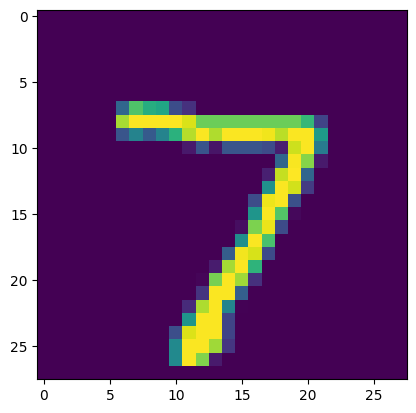

In [66]:
# image processing
import matplotlib.image as mpimg
# for ploting graphs
import matplotlib.pyplot as plt

g = plt.imshow(x_test[0][:,:,0])
print(y_test[0])

In [67]:
# predicted values
y_pred_enc = mejor_modelo.predict(x_test)
print(y_pred_enc.shape)

# actual
#y_act = [np.argmax(i) for i in y_test]

# decoding predicted values
y_pred = [np.argmax(i) for i in y_pred_enc]
y_pred= list(map(int, y_pred))
y_act = y_test

print(y_pred_enc[0])
print(y_pred)
print(y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
(10000, 10)
[3.1237338e-08 5.5193082e-06 6.6827684e-05 1.1711702e-06 9.2107977e-10
 2.3320113e-09 1.9995773e-13 9.9992633e-01 4.6320738e-09 1.6490185e-07]
[7, 2, 1, 0, 4, 1, 4, 9, 5, 9, 0, 6, 9, 0, 1, 5, 9, 7, 3, 4, 9, 6, 6, 5, 4, 0, 7, 4, 0, 1, 3, 1, 3, 4, 7, 2, 7, 1, 2, 1, 1, 7, 4, 2, 3, 5, 1, 2, 4, 4, 6, 3, 5, 5, 6, 0, 4, 1, 9, 5, 7, 8, 9, 3, 7, 4, 6, 4, 3, 0, 7, 0, 2, 9, 1, 7, 3, 2, 9, 7, 7, 6, 2, 7, 8, 4, 7, 3, 6, 1, 3, 6, 9, 3, 1, 4, 1, 7, 6, 9, 6, 0, 5, 4, 9, 9, 2, 1, 9, 4, 8, 7, 3, 9, 7, 9, 4, 4, 9, 2, 5, 4, 7, 6, 7, 9, 0, 5, 8, 5, 6, 6, 5, 7, 8, 1, 0, 1, 6, 4, 6, 7, 3, 1, 7, 1, 8, 2, 0, 2, 9, 9, 5, 5, 1, 5, 6, 0, 2, 4, 4, 6, 5, 4, 6, 5, 4, 5, 1, 4, 4, 7, 2, 3, 2, 7, 1, 8, 1, 8, 1, 8, 5, 0, 3, 9, 2, 5, 0, 1, 1, 1, 0, 9, 0, 3, 1, 6, 4, 2, 3, 6, 1, 1, 1, 3, 9, 5, 2, 9, 4, 5, 9, 3, 9, 0, 3, 6, 5, 5, 7, 2, 2, 7, 1, 2, 8, 4, 1, 7, 3, 3, 8, 8, 7, 9, 2, 2, 4, 1, 5, 9, 8, 7, 2, 3, 0, 6, 4, 2, 4, 1, 9, 5, 7, 7, 2, 8, 2, 6, 8, 5, 7, 7, 9, 1, 8, 1,

In [68]:
from sklearn.metrics import classification_report
print(classification_report(y_act, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.98      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.97      0.98      0.97      1032
           3       0.98      0.99      0.98      1010
           4       0.98      0.99      0.99       982
           5       0.99      0.98      0.98       892
           6       0.99      0.98      0.98       958
           7       0.96      0.97      0.97      1028
           8       0.99      0.98      0.98       974
           9       0.98      0.97      0.98      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



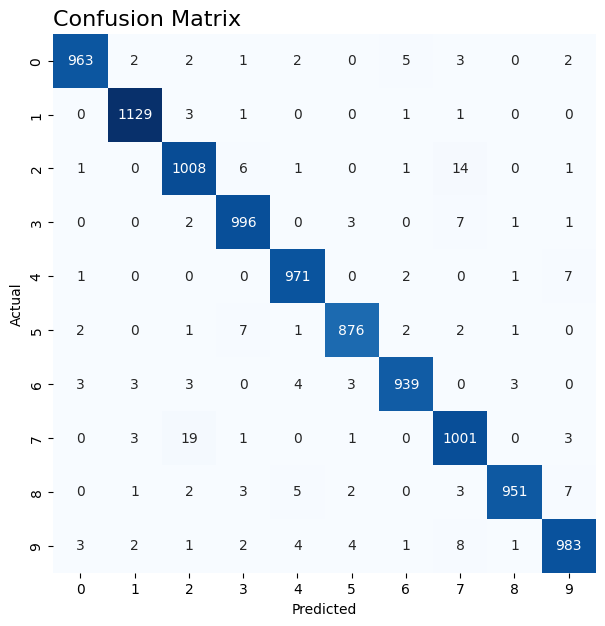

In [69]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
fig, ax = plt.subplots(figsize=(7, 7))
sns.heatmap(confusion_matrix(y_act, y_pred), annot=True,
            cbar=False, fmt='1d', cmap='Blues', ax=ax)
ax.set_title('Confusion Matrix', loc='left', fontsize=16)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.show()

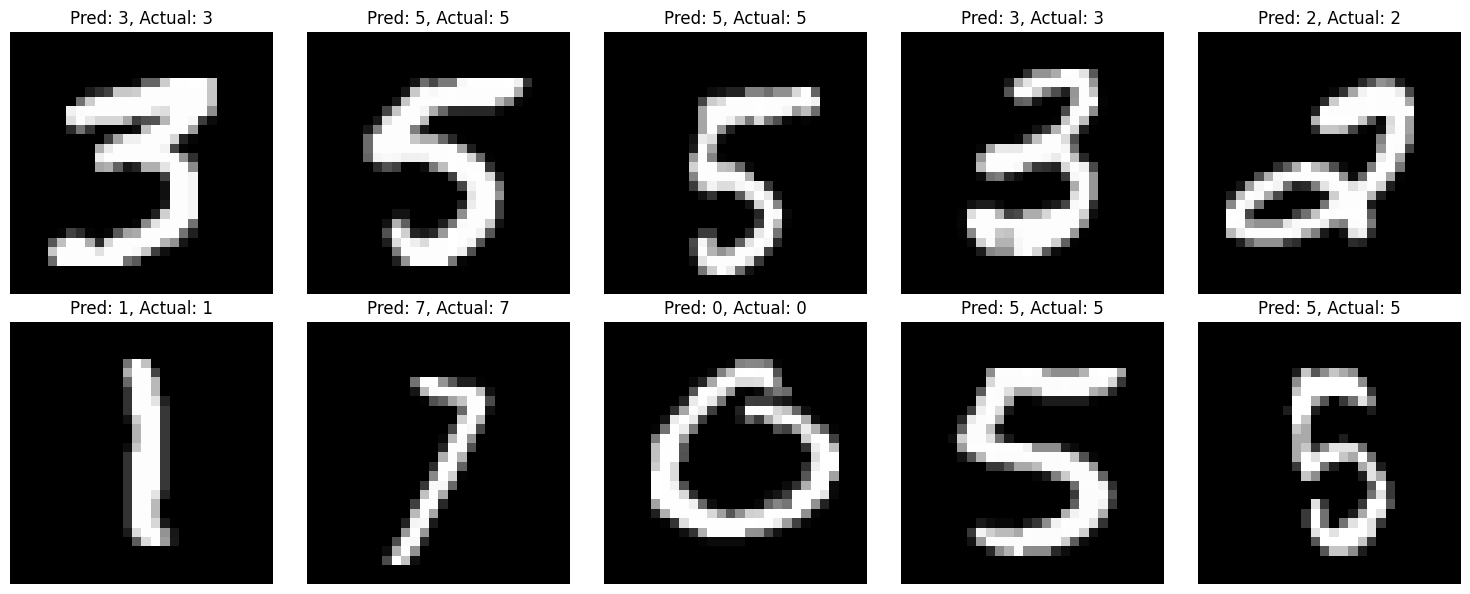

In [70]:
import random

# Generate 10 random indices
indices_aleatorios = random.sample(range(len(y_pred)), 10)

# Get the predicted values for the random indices
numeros_aleatorios = [y_pred[i] for i in indices_aleatorios]

# Get the corresponding actual values
actual_values = [y_act[i] for i in indices_aleatorios]

# Get the corresponding images
images_aleatorias = [x_test[i] for i in indices_aleatorios]


# Plot the images and their predictions
plt.figure(figsize=(15, 6))  # Adjust figure size as needed

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(images_aleatorias[i][:, :, 0], cmap='gray')
    plt.title(f"Pred: {numeros_aleatorios[i]}, Actual: {actual_values[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()
